In [1]:
import pandas as pd
from sqlalchemy import create_engine, inspect
from sqlalchemy.orm import sessionmaker
import matplotlib.pyplot as plt

In [2]:
# connect to the database
db_path = "/home/locascio/mydata/YServer/experiments/rchrono_comments.db"
engine = create_engine(f"sqlite:///{db_path}")
# session = sessionmaker(bind=engine)()

In [3]:
# Step 3: Inspect Database Structure

inspector = inspect(engine)
table_names = inspector.get_table_names()
print("Tables in the database:")
print(table_names)

Tables in the database:
['article_topics', 'articles', 'emotions', 'follow', 'hashtags', 'images', 'interests', 'mentions', 'post', 'post_emotions', 'post_hashtags', 'post_topics', 'reactions', 'recommendations', 'rounds', 'user_interest', 'user_mgmt', 'voting', 'websites']


In [ ]:
if "follow" in table_names:
    # Load the "follow" table into a Pandas DataFrame using a direct SQL query
    follow_df = pd.read_sql_query("SELECT * FROM follow", engine)
else:
    raise ValueError("'follow' table not found in the database.")

print("First 5 rows of the 'follow' table:")
print(follow_df.head())

# Basic statistics
print("Summary statistics of numeric columns in 'follow':")
print(follow_df.describe())

First 5 rows of the 'follow' table:
   user_id  follower_id  id  action  round
0       15           84   1  follow      1
1      321           70   2  follow      2
2      233           84   3  follow      2
3       86          289   4  follow      2
4       86           70   5  follow      2
Summary statistics of numeric columns in 'follow':
           user_id  follower_id           id        round
count  2586.000000  2586.000000  2586.000000  2586.000000
mean    252.499613   248.961330  1293.500000   353.465197
std     142.010001   144.516126   746.658222   202.099029
min       1.000000     1.000000     1.000000     1.000000
25%     134.250000   123.250000   647.250000   181.000000
50%     261.000000   254.000000  1293.500000   347.000000
75%     377.000000   377.000000  1939.750000   523.750000
max     498.000000   498.000000  2586.000000   720.000000
Column names in 'follow':
Index(['user_id', 'follower_id', 'id', 'action', 'round'], dtype='object')


In [18]:
df = follow_df
steps = 24

In [23]:
# Create a grouping column by dividing the round by 24
df['group'] = (df['round'] - 1) // steps

# Group by the new column and process the data into separate columns
grouped = df.groupby('group').apply(lambda group: pd.Series({
    'adjacency_matrix': group[['user_id', 'follower_id']].to_numpy(),
    'action': group['action'].tolist(),
    #'round': group['round'].tolist()
}))

# Reset index for readability (optional)
grouped.reset_index(drop=True, inplace=True)
# Display grouped data
grouped

/tmp/ipykernel_2104481/2037752285.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('group').apply(lambda group: pd.Series({


,adjacency_matrix,action
0,"[[15, 84], [321, 70], [233, 84], [86, 289], [8...","[follow, follow, follow, follow, follow, follo..."
1,"[[171, 26], [34, 289], [391, 84], [201, 419], ...","[follow, follow, follow, follow, follow, follo..."
2,"[[335, 62], [118, 62], [158, 58], [158, 285], ...","[follow, follow, follow, follow, follow, follo..."
3,"[[262, 31], [262, 395], [183, 360], [100, 398]...","[follow, follow, unfollow, follow, follow, fol..."
4,"[[215, 31], [489, 26], [489, 151], [159, 199],...","[follow, follow, follow, follow, follow, follo..."
5,"[[1, 8], [40, 8], [40, 31], [307, 438], [40, 3...","[follow, follow, follow, follow, follow, follo..."
6,"[[487, 190], [487, 95], [9, 85], [272, 487], [...","[follow, follow, follow, follow, follow, follo..."
7,"[[394, 473], [394, 145], [51, 16], [210, 14], ...","[follow, follow, follow, follow, follow, follo..."
8,"[[146, 357], [325, 450], [22, 441], [298, 441]...","[follow, follow, follow, follow, follow, follo..."
9,"[[488, 8], [159, 56], [398, 120], [175, 57], [...","[follow, follow, follow, follow, follow, follo..."


Errors: [(132, 155)]
Errors: [(306, 146)]
Errors: [(306, 136)]
Errors: [(306, 136)]


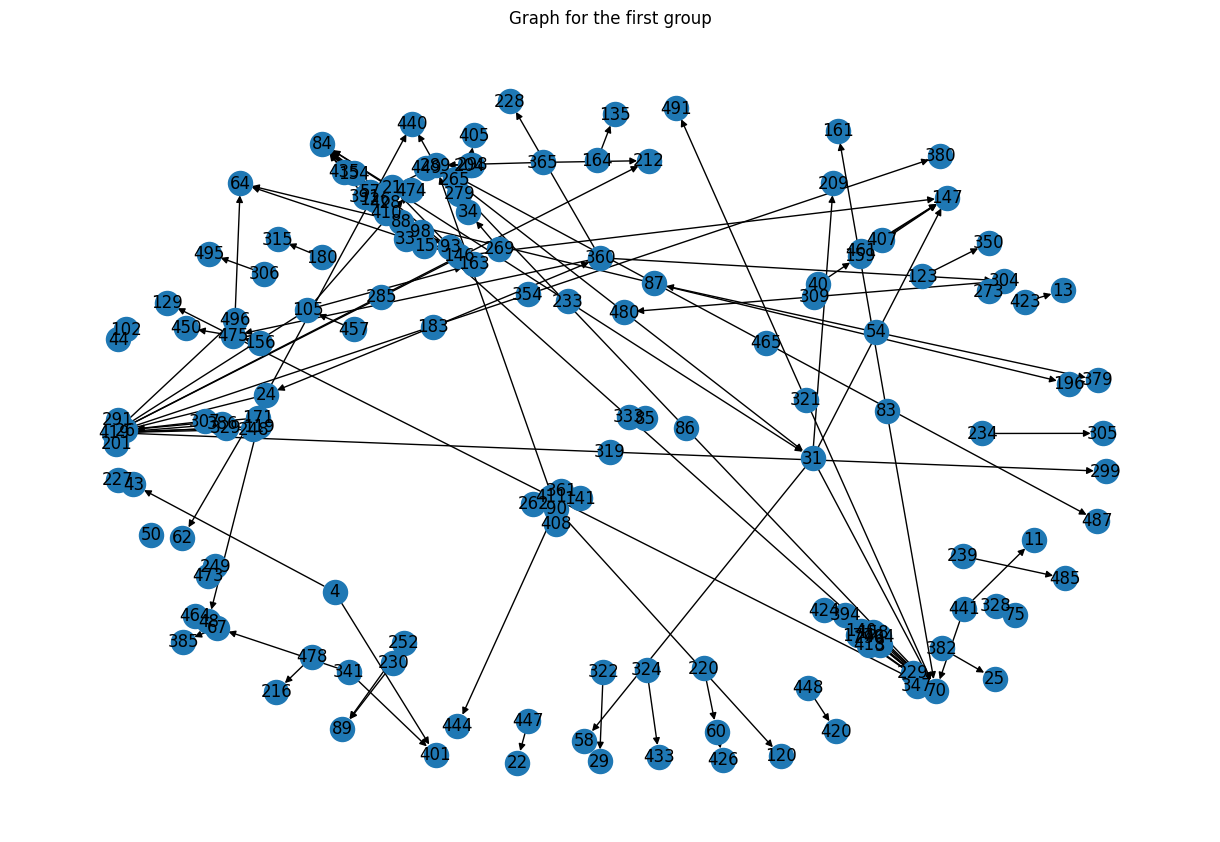

In [55]:
# for each list of adjacency matrices, create a graph, add a link if the action is follow and remove it if the action is unfollow
import networkx as nx
import numpy as np

def create_graph(adjacency_matrix, actions, old_G=None):
    errors = []
    G = nx.DiGraph(old_G)
    # Add edges to the graph
    for i, (user_id, follower_id) in enumerate(adjacency_matrix):
        if actions[i] == 'follow':
            G.add_edge(user_id, follower_id)
        elif actions[i] == 'unfollow':
            try:
                G.remove_edge(user_id, follower_id)
            except:
                errors.append((user_id, follower_id))
    return G, errors


# Create a graph for each group
graphs = []
G = None
for adjacency_matrix, actions in zip(grouped['adjacency_matrix'], grouped['action']):
    G, e = create_graph(adjacency_matrix, actions, G)
    print(f"Errors: {e}") if len(e) > 0 else None
    graphs.append(G)
# [create_graph(adjacency_matrix, actions) for adjacency_matrix, actions in zip(grouped['adjacency_matrix'], grouped['action'])]

# Plot the graph for the first group
plt.figure(figsize=(12, 8))
nx.draw(graphs[1], with_labels=True)
plt.title('Graph for the first group')
plt.show()

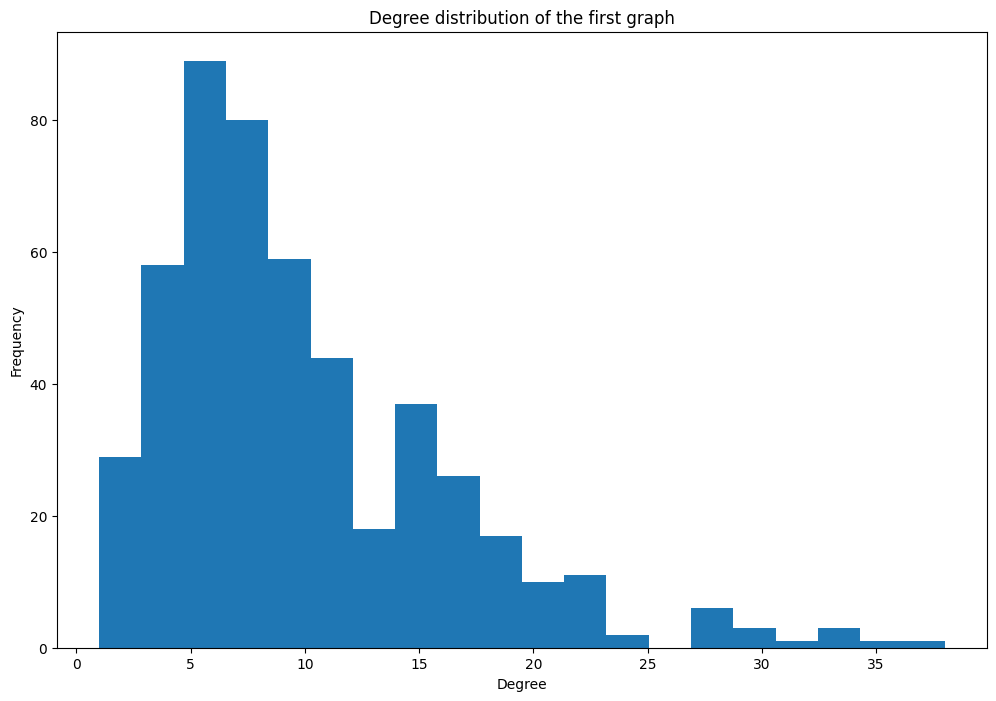

In [ ]:
# Create a list to store the degree distribution of each node
degree_distributions = []
# Iterate over the graphs
for G in graphs:
    # Get the degree of each node in the graph
    degrees = dict(G.degree())
    # Get the degree distribution of the graph
    degree_distribution = np.array(list(degrees.values()))
    # Append the degree distribution to the list
    degree_distributions.append(degree_distribution)

# Plot the degree distribution of the first graph
plt.figure(figsize=(12, 8))
plt.hist(degree_distributions[29], bins=20)
plt.title('Degree distribution of the first graph')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()


In [48]:
nodes = graphs[-1].number_of_nodes()
density = [G.number_of_edges() / (nodes*(nodes-1)) for G in graphs]

In [51]:
graphs[-1].number_of_edges()

2439

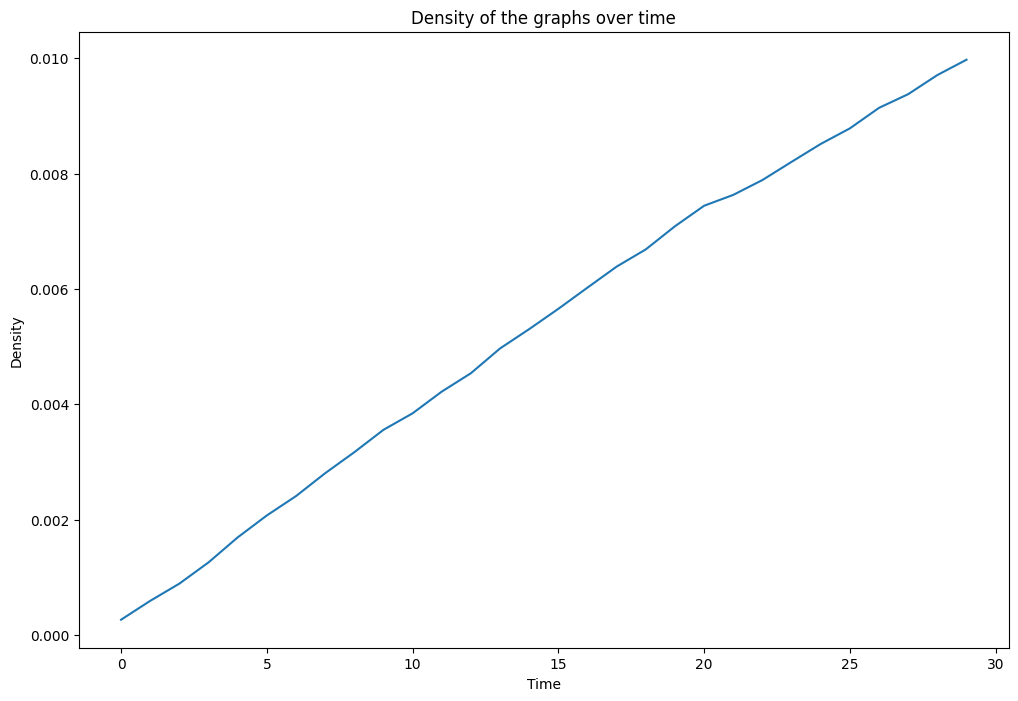

In [52]:
plt.figure(figsize=(12, 8))
plt.plot(density)
plt.title('Density of the graphs over time')
plt.xlabel('Time')
plt.ylabel('Density')
plt.show()
